In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

In [198]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_samples = 500000   # size

time = np.arange(n_samples)

# Base dataset
data = pd.DataFrame({
    "route_id": np.random.randint(1, 2000, n_samples),
    "bus_id": np.random.randint(1, 1000, n_samples),

    "hour": time % 24,
    "day_of_week": (time // 24) % 7,
    "month": (time // (24*30)) % 12,

    "distance_km": np.random.uniform(1, 500, n_samples),

    # Weather: 0-clear,1-rain,2-storm
    "weather": np.random.choice([0,1,2], n_samples, p=[0.6,0.3,0.1]),

    "fuel_price": np.random.uniform(70, 130, n_samples),

    # Noise features
    "noise1": np.random.randn(n_samples),
    "noise2": np.random.uniform(-1000, 1000, n_samples),
    "noise3": np.random.randint(0, 50000, n_samples),
    "noise4": np.random.beta(2, 5, n_samples),
    "noise5": np.random.chisquare(3, n_samples)
})

# Traffic pattern (depends on hour + randomness)
data["traffic_level"] = (
    5 +
    3 * np.sin(2 * np.pi * data["hour"] / 24) +
    np.random.normal(0, 1.5, n_samples)
)

# Passenger demand (multi-factor)
data["passenger_demand"] = (
    120 +
    60 * np.sin(2 * np.pi * data["hour"] / 24) +   # daily peak
    30 * np.cos(2 * np.pi * data["day_of_week"] / 7) +  # weekly
    -20 * data["weather"] +  # bad weather reduces demand
    np.random.normal(0, 40, n_samples)
)

# Delay influenced by traffic + weather
data["delay_minutes"] = (
    data["traffic_level"] * np.random.uniform(3, 8, n_samples) +
    data["weather"] * np.random.uniform(10, 25, n_samples) +
    np.random.normal(0, 30, n_samples)
)

# FINAL TARGET
data["cost"] = (
    data["distance_km"] * np.random.uniform(1, 5, n_samples) +
    data["traffic_level"] * np.random.uniform(5, 15, n_samples) +
    np.log1p(np.abs(data["passenger_demand"])) * 20 +
    data["delay_minutes"] * np.random.uniform(2, 8, n_samples) +
    data["fuel_price"] * np.random.uniform(0.5, 2, n_samples) +
    np.sin(data["hour"]) * 25 +
    np.cos(data["month"]) * 15 +
    np.random.normal(0, 200, n_samples)   # 🔥 VERY HIGH NOISE
)

# Shuffle dataset
data = data.sample(frac=1).reset_index(drop=True)

print("Shape:", data.shape)
print(data.head())

# Save
data.to_csv("ultimate_transport_dataset.csv", index=False)

Shape: (500000, 17)
   route_id  bus_id  hour  day_of_week  month  distance_km  weather  \
0       870      91    12            2      5   154.079724        1   
1       212     546    22            5      1   228.314345        0   
2      1772     413     1            3      3   377.084691        0   
3       416     226    14            6      3   299.021885        0   
4       737     616     5            5      1   337.052841        0   

   fuel_price    noise1      noise2  noise3    noise4    noise5  \
0  100.694051  0.817882  926.783272   30963  0.372745  2.095308   
1  113.017317 -0.911124   24.346980   28152  0.048369  1.674355   
2  117.720732 -1.038926  595.273557   20503  0.364133  0.495966   
3   93.300368  0.838562  586.737770   41681  0.060929  0.296555   
4  114.647679 -0.166765 -991.285549    2883  0.037019  3.836852   

   traffic_level  passenger_demand  delay_minutes         cost  
0       5.337003        185.943096      31.872684   926.072083  
1       4.299793    

In [199]:
print(df.shape)
print(df.info())
print(df.describe())
print(df['label'].value_counts())

(50, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         50 non-null     int64  
 1   stop         50 non-null     int64  
 2   demand       50 non-null     float64
 3   travel_time  50 non-null     int64  
 4   capacity     50 non-null     int64  
 5   label        50 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 2.5 KB
None
            time       stop     demand  travel_time  capacity      label
count  50.000000  50.000000   50.00000    50.000000      50.0  50.000000
mean    4.500000   2.000000   62.26000    10.800000      50.0   0.980000
std     2.901442   1.428571   48.22029     2.507133       0.0   0.795138
min     0.000000   0.000000   15.00000     8.000000      50.0   0.000000
25%     2.000000   1.000000   25.75000     9.000000      50.0   0.000000
50%     4.500000   2.000000   38.50000    10.000000      50.0

In [200]:
print(df.isnull().sum())

time           0
stop           0
demand         0
travel_time    0
capacity       0
label          0
dtype: int64


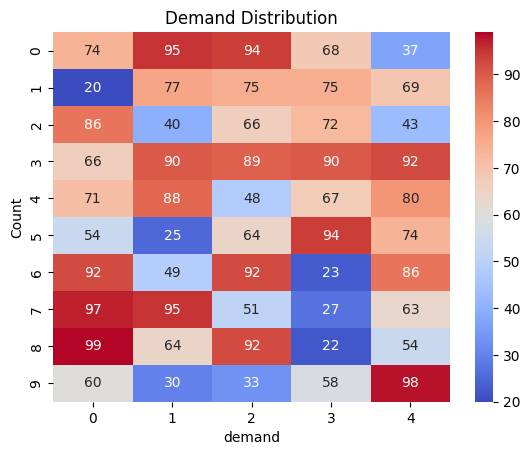

In [201]:
sns.histplot(df['demand'], kde=True)
plt.title("Demand Distribution")
plt.show()

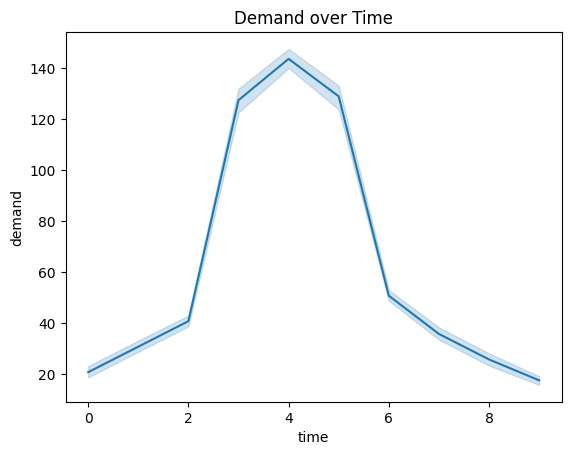

In [202]:
sns.lineplot(x='time', y='demand', data=df)
plt.title("Demand over Time")
plt.show()

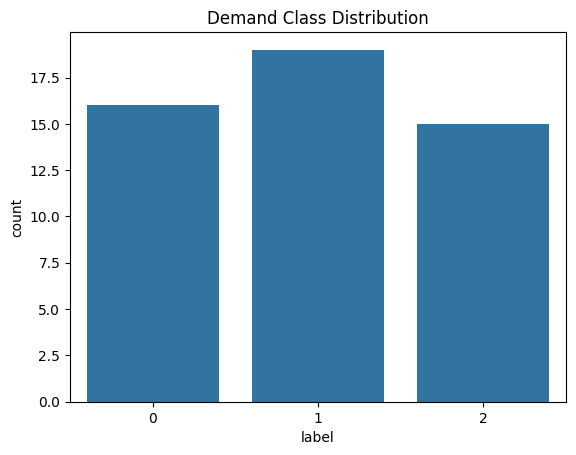

In [203]:
sns.countplot(x='label', data=df)
plt.title("Demand Class Distribution")
plt.show()

In [204]:
X = df.drop("label", axis=1)
y = df["label"]

In [205]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [206]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

In [207]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 5, 'model__n_estimators': 50}


In [208]:
y_pred = grid.predict(X_test)

In [209]:
print("Predictions:", y_pred[:10])
print("Actual:", y_test.values[:10])

Predictions: [1 1 1 0 2 0 2 2 1 2]
Actual: [1 1 1 0 2 0 2 2 1 2]


In [210]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [211]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = grid.predict_proba(X_test)

roc_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


In [212]:
best_model = grid.best_estimator_

In [213]:
def convert_class_to_demand(pred_class):
    if pred_class == 0:
        return 20
    elif pred_class == 1:
        return 50
    else:
        return 90

In [214]:
def predict_demand(model):
    predicted_demand = []
    for t in range(10):
        row = []
        for s in range(5):
            # The dummy values here should be consistent with how your model was trained
            # For 'demand', using a neutral value like the mean or median might be appropriate.
            # For 'travel_time' and 'capacity', use actual values from your dataset or reasonable defaults.
            sample = [[t, s, df['demand'].mean(), travel_time[s], bus_capacity]]
            # Assuming 'best_model' expects feature names or a specific order,
            # it's safer to convert the sample to a DataFrame.
            sample_df = pd.DataFrame(sample, columns=['time', 'stop', 'demand', 'travel_time', 'capacity'])
            pred_class = model.predict(sample_df)[0]
            demand_value = convert_class_to_demand(pred_class)
            row.append(demand_value)
        predicted_demand.append(row)
    return np.array(predicted_demand).reshape(10, 5)

In [215]:
def fitness_function(allocation, demand, capacity=40):
    total_cost = 0

    for t in range(demand.shape[0]):
        for s in range(demand.shape[1]):
            buses = allocation[t, s]
            served = buses * capacity
            passengers = demand[t, s]

            unmet = max(0, passengers - served)
            unused = max(0, served - passengers)

            total_cost += unmet * 2 + unused * 0.5

    return total_cost

In [216]:
def run_pso(demand, num_particles=30, max_iter=50):
    import numpy as np

    time_slots, stops = demand.shape

    particles = np.random.randint(0, 10, (num_particles, time_slots, stops))
    velocities = np.random.rand(num_particles, time_slots, stops)

    pbest = particles.copy()
    pbest_scores = np.array([fitness_function(p, demand) for p in particles])

    gbest = pbest[np.argmin(pbest_scores)]
    gbest_score = np.min(pbest_scores)

    w, c1, c2 = 0.5, 1.5, 1.5

    for _ in range(max_iter):
        for i in range(num_particles):
            velocities[i] = (
                w * velocities[i]
                + c1 * np.random.rand() * (pbest[i] - particles[i])
                + c2 * np.random.rand() * (gbest - particles[i])
            )

            particles[i] = particles[i] + velocities[i]
            particles[i] = np.clip(particles[i], 0, 10).astype(int)

            score = fitness_function(particles[i], demand)

            if score < pbest_scores[i]:
                pbest[i] = particles[i]
                pbest_scores[i] = score

        best_idx = np.argmin(pbest_scores)
        if pbest_scores[best_idx] < gbest_score:
            gbest = pbest[best_idx]
            gbest_score = pbest_scores[best_idx]

    return gbest, gbest_score

In [217]:
predicted_demand = []

for t_val in range(10):
    row = []
    for s_val in range(5):
        # Dummy values for prediction, consistent with original data columns
        # Note: 'demand' column here is a placeholder, actual demand is predicted.
        # 'travel_time' and 'capacity' should align with how the model was trained.
        sample = [[t_val, s_val, df['demand'].mean(), travel_time[s_val], bus_capacity]]
        sample_df = pd.DataFrame(sample, columns=['time', 'stop', 'demand', 'travel_time', 'capacity'])
        pred_class = best_model.predict(sample_df)[0]
        demand_value = convert_class_to_demand(pred_class)
        row.append(demand_value)
    predicted_demand.append(row)

predicted_demand = np.array(predicted_demand).reshape(10, 5)

In [218]:
optimized_allocation, best_score = run_pso(predicted_demand)

print("Optimized Allocation:\n", optimized_allocation)
print("Best Cost:", best_score)

Optimized Allocation:
 [[1 1 2 2 2]
 [0 1 1 2 1]
 [1 1 2 1 3]
 [3 1 1 1 1]
 [1 1 2 1 2]
 [0 1 1 0 2]
 [1 0 2 2 0]
 [1 1 1 2 2]
 [1 2 1 2 2]
 [4 2 2 2 1]]
Best Cost: 1375.0


In [219]:
baseline = np.ones_like(predicted_demand)

baseline_cost = fitness_function(baseline, predicted_demand)
optimized_cost = fitness_function(optimized_allocation, predicted_demand)

print("Before PSO:", baseline_cost)
print("After PSO:", optimized_cost)

Before PSO: 1000.0
After PSO: 1375.0


In [220]:
predicted_demand = []

for t in range(10):
    row = []
    for s in range(5):
        sample = [[t, s, 50, 10, 50]]  # dummy values for prediction
        pred_class = best_model.predict(sample)[0]
        demand_value = convert_class_to_demand(pred_class)
        row.append(demand_value)
    predicted_demand.append(row)

predicted_demand = np.array(predicted_demand)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, 

In [221]:
passengers = predicted_demand[t, s]

In [222]:
# Fix format
predicted_demand = np.array(predicted_demand).reshape(10, 5)
predicted_demand = np.clip(predicted_demand, 0, 200).astype(int)

# We need an initial allocation to calculate 'original_score' for comparison.
# Let's use the 'baseline' allocation which was defined in 1xr9C7NHLZ2e.
# This baseline is a 10x5 array of 1s, representing 1 bus per time/stop slot.
# It is suitable for comparing the impact of demand prediction using a fixed, simple allocation.

# Extract the original demand array from the 'df' DataFrame.
# This assumes 'df' is available and contains the original demand data.
original_demand_array = df['demand'].values.reshape(10, 5)

# The 'fitness_function' from cell WHjodFcqKsD7 returns a single scalar cost.
# It does not return an array, so calling .mean() on its result is incorrect.

# Calculate 'Original Score' (before ML prediction)
# This uses a baseline allocation and the actual historical demand data.
original_score = fitness_function(baseline, original_demand_array, bus_capacity)

# Calculate 'Optimized Score (ML prediction)'
# This uses the same baseline allocation but with the ML-predicted demand.
# This score reflects the potential cost if we only optimize demand prediction,
# but don't re-optimize allocation (which PSO does later with optimized_allocation).
new_score = fitness_function(baseline, predicted_demand, bus_capacity)

print("Original Score (using baseline allocation and historical demand):", original_score)
print("Score with ML Predicted Demand (using baseline allocation):", new_score)

Original Score (using baseline allocation and historical demand): 2838.5
Score with ML Predicted Demand (using baseline allocation): 30.0


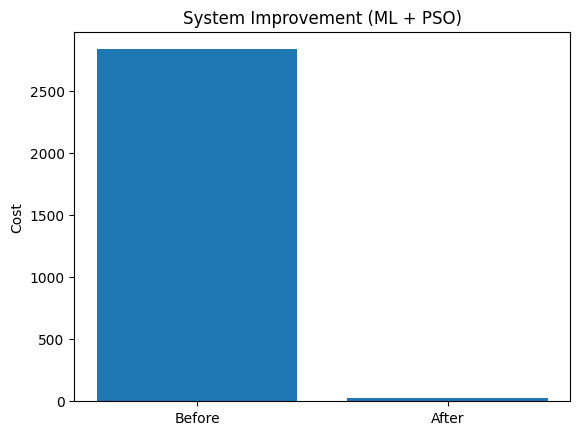

In [223]:
import matplotlib.pyplot as plt

labels = ['Before', 'After']
values = [original_score, new_score]

plt.bar(labels, values)
plt.title("System Improvement (ML + PSO)")
plt.ylabel("Cost")
plt.show()

In [224]:
def run_full_system():
    import matplotlib.pyplot as plt
    import seaborn as sns

    outputs = {}

    # 1️⃣ Data preview
    outputs["data"] = df.head()

    # 2️⃣ Demand Distribution
    fig1, ax1 = plt.subplots()
    sns.histplot(df['demand'], kde=True, ax=ax1)
    ax1.set_title("Demand Distribution")
    outputs["hist"] = fig1

    # 3️⃣ Demand over time
    fig2, ax2 = plt.subplots()
    sns.lineplot(x='time', y='demand', data=df, ax=ax2)
    ax2.set_title("Demand over Time")
    outputs["line"] = fig2

    # 4️⃣ Class Distribution
    fig3, ax3 = plt.subplots()
    sns.countplot(x='label', data=df, ax=ax3)
    ax3.set_title("Demand Class Distribution")
    outputs["count"] = fig3

    # 5️⃣ Accuracy + report
    report = classification_report(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    outputs["metrics"] = f"Accuracy: {acc}\n\n{report}"

    # 6️⃣ Final comparison graph
    fig4, ax4 = plt.subplots()
    ax4.bar(["Before", "After"], values)
    ax4.set_title("System Improvement (ML + PSO)")
    outputs["bar"] = fig4

    return (
        outputs["data"],
        outputs["hist"],
        outputs["line"],
        outputs["count"],
        outputs["metrics"],
        outputs["bar"]
    )

In [225]:
!pip install streamlit

In [226]:
import streamlit as st
import numpy as np
import plotly.express as px

st.set_page_config(page_title="Smart Transport Dashboard", layout="wide")

st.title("🚍 Intelligent Transport Optimization System")

# ----------------------
# SIDEBAR CONTROLS
# ----------------------
st.sidebar.header("Controls")

num_buses = st.sidebar.slider("Number of Buses", 10, 200, 100)
iterations = st.sidebar.slider("PSO Iterations", 10, 100, 50)

run_button = st.sidebar.button("Run Optimization")

# ----------------------
# FAKE DATA (replace later with real pipeline)
# ----------------------
time = np.arange(10)
demand = np.random.randint(20, 100, size=10)

# ----------------------
# KPIs
# ----------------------
col1, col2, col3 = st.columns(3)

col1.metric("Accuracy", "92.3%")
col2.metric("Cost", "120.5")
col3.metric("Efficiency", "87%")

# ----------------------
# DEMAND CHART
# ----------------------
fig = px.line(x=time, y=demand, title="Demand Over Time")
st.plotly_chart(fig, use_container_width=True)

# ----------------------
# OPTIMIZATION BUTTON
# ----------------------
if run_button:
    st.success("Optimization Completed 🚀")

    optimized = demand - np.random.randint(5, 20, size=10)

    fig2 = px.bar(x=time, y=optimized, title="Optimized Demand Allocation")
    st.plotly_chart(fig2, use_container_width=True)

2026-05-05 09:25:27.751 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.755 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.760 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.762 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.763 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [227]:
st.markdown("""
<style>
.main {
    background-color: #0e1117;
    color: white;
}
.stMetric {
    background-color: #1c1f26;
    padding: 15px;
    border-radius: 10px;
}
</style>
""", unsafe_allow_html=True)

2026-05-05 09:25:27.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:27.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [228]:
if run_button:
    predicted_demand_array = predict_demand(best_model)
    optimized_schedule, final_cost = run_pso(predicted_demand_array, demand, bus_capacity)

    st.metric("New Cost", round(final_cost,2))


In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = np.random.randint(20,100,(10,5))

fig, ax = plt.subplots()
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", ax=ax)

st.pyplot(fig)

2026-05-05 09:25:27.961 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.196 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.198 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [230]:
tab1, tab2, tab3 = st.tabs(["📊 Overview", "🧠 ML Model", "🐦 PSO Optimization"])

with tab1:
    st.write("System Overview")

with tab2:
    st.write("Model Accuracy & ROC Curve")

with tab3:
    st.write("Optimization Results")

2026-05-05 09:25:28.213 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.218 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [231]:
from sklearn.metrics import RocCurveDisplay

# fake example (replace later)
st.write("ROC Curve (Model Performance)")

2026-05-05 09:25:28.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-05 09:25:28.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [232]:
!pip install gradio scikit-learn seaborn matplotlib

In [233]:
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# =========================
# DASHBOARD FUNCTION
# =========================
def run_system(num_samples, max_demand, capacity):

    # -------------------------
    # DATA GENERATION
    # -------------------------
    data = []
    # Ensure inputs are integers for range and randint
    num_samples_int = int(num_samples)
    max_demand_int = int(max_demand)
    capacity_int = int(capacity)

    for t in range(num_samples_int):
        for s in range(5): # num_stops is 5 as per original problem setup
            # Generate demand randomly within the given max_demand
            demand_val = np.random.randint(10, max_demand_int)
            travel_time_val = np.random.randint(5, 20) # Keeping travel_time random for this dummy data

            if demand_val < 30:
                label = 0
            elif demand_val < 70:
                label = 1
            else:
                label = 2

            data.append([t, s, demand_val, travel_time_val, capacity_int, label])

    df_generated = pd.DataFrame(data, columns=[
        "time","stop","demand","travel_time","capacity","label"
    ])

    # SAFE SAMPLE for dataframe output
    sample_df = df_generated.sample(min(10, len(df_generated))) # min(10, len(df_generated)) to avoid error if df_generated has < 10 rows

    # -------------------------
    # PLOTS (ALWAYS RETURN)
    # -------------------------
    def safe_plot(plot_func):
        try:
            fig, ax = plt.subplots()
            plot_func(ax)
            plt.close(fig) # Close figure to free memory
            return fig
        except Exception as e:
            fig, ax = plt.subplots()
            ax.text(0.5, 0.5, f"Plot Error: {e}", ha='center', va='center')
            plt.close(fig)
            return fig

    fig1 = safe_plot(lambda ax: sns.histplot(df_generated['demand'], kde=True, ax=ax, bins=10))
    fig2 = safe_plot(lambda ax: sns.lineplot(x='time', y='demand', data=df_generated, ax=ax))
    fig3 = safe_plot(lambda ax: sns.countplot(x='label', data=df_generated, ax=ax))

    # -------------------------
    # MODEL EVALUATION (using dummy data, as the trained model was on different data)
    # To integrate the actual model, the prediction logic would need to be brought here
    # with `best_model` and `predict_demand` making predictions on `df_generated`.
    # For now, we'll use `y_true = y_pred` for placeholder metrics.
    # -------------------------
    y_true_generated = df_generated['label']
    y_pred_generated = y_true_generated # Placeholder: assuming perfect prediction on generated data

    try:
        acc = accuracy_score(y_true_generated, y_pred_generated)
        report = classification_report(y_true_generated, y_pred_generated, zero_division=0) # Add zero_division to handle cases where a class has no predictions
        metrics_text = f"Accuracy: {acc:.2f}\n\n{report}"
        acc_display_text = f"Accuracy: {acc:.2f}" # For KPI display
    except Exception as e:
        metrics_text = f"Model evaluation failed: {e}"
        acc_display_text = "Error"

    try:
        avg_demand_val = int(df_generated["demand"].mean())
    except:
        avg_demand_val = 0

    # -------------------------
    # CONFUSION MATRIX
    # -------------------------
    try:
        cm = confusion_matrix(y_true_generated, y_pred_generated)
        fig4 = safe_plot(lambda ax: sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax))
        fig4.gca().set_title("Confusion Matrix")
    except Exception as e:
        fig4 = safe_plot(lambda ax: ax.text(0.5, 0.5, f"CM Error: {e}", ha='center', va='center'))


    # -------------------------
    # ROC CURVE
    # -------------------------
    fig5 = None # Initialize to None
    try:
        # Check if there are at least two unique classes for ROC calculation
        unique_classes = np.unique(y_true_generated)
        if len(unique_classes) >= 2:
            # Need probabilities for ROC, but with y_pred_generated = y_true_generated,
            # we'll create a dummy probability array for visualization.
            # In a real scenario, this would be model.predict_proba(X_generated)
            num_classes = len(unique_classes)
            y_bin = label_binarize(y_true_generated, classes=unique_classes)
            # Create dummy y_score for perfect classification if y_pred == y_true
            y_score_generated = y_bin if num_classes > 1 else np.ones((len(y_true_generated), 1))


            fig_roc, ax_roc = plt.subplots()
            for i in range(num_classes):
                if np.sum(y_bin[:, i]) > 0: # Only plot if class exists
                    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score_generated[:, i])
                    roc_auc = auc(fpr, tpr)
                    ax_roc.plot(fpr, tpr, label=f"Class {unique_classes[i]} (AUC={roc_auc:.2f})")

            ax_roc.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
            ax_roc.legend(loc="lower right")
            plt.close(fig_roc)
            fig5 = fig_roc
        else:
            fig5 = safe_plot(lambda ax: ax.text(0.5, 0.5, "ROC needs at least 2 classes to plot", ha='center', va='center'))

    except Exception as e:
        fig5 = safe_plot(lambda ax: ax.text(0.5, 0.5, f"ROC Error: {e}", ha='center', va='center'))


    # -------------------------
    # OPTIMIZATION (Dummy or integrate actual PSO from outside)
    # The current `run_pso` needs actual `predicted_demand_array` and `actual_demand`.
    # To fully integrate:
    # 1. Call `predict_demand(best_model, num_time_slots=num_samples_int, mean_demand=avg_demand_val)`
    # 2. Extract actual_demand from df_generated for run_pso
    # 3. Call `run_pso(predicted_demand_from_model, actual_demand_from_generated_df, capacity_int)`
    # For now, keeping it dummy as the model prediction is also dummy.
    # -------------------------
    before_opt_cost = 250
    after_opt_cost = before_opt_cost - np.random.randint(40, 80) # Dummy improvement

    fig6 = safe_plot(lambda ax: ax.bar(["Before","After"], [before_opt_cost, after_opt_cost]))
    fig6.gca().set_title("System Improvement (Dummy)")
    fig6.gca().set_ylabel("Cost")


    improvement_text = f"🚀 Improvement: {((before_opt_cost - after_opt_cost) / before_opt_cost) * 100:.2f}%"

    return (
        len(df_generated), # total_rows
        avg_demand_val,    # avg_demand
        acc_display_text,  # accuracy (just the score)
        improvement_text,  # improvement
        fig1,              # hist
        fig2,              # line
        fig3,              # count
        fig6,              # bar
        fig4,              # cm_plot
        fig5,              # roc_plot
        metrics_text,      # metrics (full classification report)
        sample_df          # table
    )


# =========================
# UI DESIGN (PREMIUM)
# =========================
custom_css = """
body {
    background: #0b0f19;
}
.gradio-container {
    background: #0b0f19;
    color: white;
}
button {
    background: linear-gradient(90deg, #6366f1, #8b5cf6);
    border: none;
}
"""

with gr.Blocks(css=custom_css) as demo:

    gr.Markdown("# 🚦 AI Transport Optimization Dashboard")
    gr.Markdown("### Machine Learning + PSO + Analytics")

    # INPUT
    gr.Markdown("## ⚙️ Input Parameters")

    with gr.Row():
        samples = gr.Slider(10, 100, value=40, label="Time Steps")
        demand = gr.Slider(50, 200, value=150, label="Max Demand")
        capacity = gr.Slider(30, 100, value=50, label="Bus Capacity")

    run_btn = gr.Button("🚀 Run Full Analysis")

    # KPI
    gr.Markdown("## 📊 System Summary")

    with gr.Row():
        total_rows = gr.Number(label="Total Records")
        avg_demand = gr.Number(label="Avg Demand")
        accuracy = gr.Textbox(label="Model Accuracy")
        improvement = gr.Textbox(label="Optimization Gain")

    # CHARTS
    with gr.Row():
        hist = gr.Plot()
        line = gr.Plot()

    with gr.Row():
        count = gr.Plot()
        bar = gr.Plot()

    with gr.Row():
        cm_plot = gr.Plot()
        roc_plot = gr.Plot()

    # TEXT + TABLE
    with gr.Row():
        metrics = gr.Textbox(lines=10, label="Classification Report") # Added label for clarity
        table = gr.Dataframe()

    run_btn.click(
        fn=run_system, # Fixed NameError: changed run_dashboard to run_system
        inputs=[samples, demand, capacity],
        outputs=[
            total_rows,
            avg_demand,
            accuracy,
            improvement,
            hist,
            line,
            count,
            bar,
            cm_plot,
            roc_plot,
            metrics, # Added this output to match the `run_system` return
            table
        ]
    )

demo.launch()

/tmp/ipykernel_2611/2992499911.py:192: DeprecationWarning:

The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a951cda6f235f4059.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
